# FraudGraph — GPU detection pipeline + CPU-vs-GPU benchmark

**Target runtime: Google Colab with a T4 GPU** (`Runtime → Change runtime type → T4 GPU`).
Kaggle T4/P100 also works. Don't run the heavy cells on a CPU-only runtime.

Pipeline: load Parquet → ETL/features (same code on both engines) → graph build →
WCC → Louvain → PageRank (benchmark) → **Leiden community detection** → ring extraction +
risk scores → write `ring_assignments`, `ring_features`, `benchmarks` to BigQuery.

## Benchmark methodology
1. **Same machine for both engines**: this VM's CPU (pandas + NetworkX) vs this VM's GPU (cuDF + cuGraph).
2. **Identical logical operations**: the ETL runs the *same function body* for both engines — the dataframe module (`pandas` or `cudf`) is injected as a parameter. Graph stages use each library's canonical API for the same algorithm.
3. **Cold and warm timings** recorded separately (`warm` column). GPU cold runs include JIT/allocator warm-up — reported as-is.
4. **Time cap**: every CPU stage is capped at `DNF_CAP_MINUTES` (default 30). A stage that exceeds the cap is recorded as **DNF** rather than dropped from the results.
5. **Provenance**: hardware, library versions, run_id and edge count are logged into every benchmark row, and this notebook is committed to the repo so the numbers can be reproduced.
6. NetworkX `pagerank` uses its default SciPy backend — the strongest CPU baseline available, so that is what gets timed.

The CPU-vs-GPU comparison covers the standard algorithms (WCC, Louvain, PageRank), run
identically on both engines. **Leiden** does the actual ring detection (it avoids a
degenerate-community failure mode Louvain hits on this graph) and is timed on GPU only.

Data comes from `generator/generate.py` (synthetic, PaySim-seeded distributions,
ground-truth labels). Nothing here is real transaction data.

In [9]:
# 0. GPU check — expect a T4 (or L4/P100). If this fails, switch the runtime type.
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

name, memory.total [MiB], driver_version
Tesla T4, 15360 MiB, 580.82.07


In [10]:
# 1. Dependencies. Recent Colab GPU runtimes ship RAPIDS (cudf/cugraph) preinstalled;
#    install from the NVIDIA index only if missing. If the import still fails after
#    installing, do Runtime -> Restart session and rerun from the top.
try:
    import cudf, cugraph  # noqa
    print("RAPIDS present: cudf", cudf.__version__, "| cugraph", cugraph.__version__)
except ImportError:
    print("Installing RAPIDS (takes a few minutes)...")
    !pip install --quiet cudf-cu12 cugraph-cu12 --extra-index-url=https://pypi.nvidia.com
!pip install --quiet networkx psutil gcsfs google-cloud-bigquery db-dtypes pyarrow matplotlib

RAPIDS present: cudf 26.02.01 | cugraph 26.02.00


In [11]:
# 2. Configuration — edit this cell only.
import time

SCALE = "1m"                      # "1m" | "10m" | "20m" | "50m"
N_EDGES = {"1m": 1_000_000, "10m": 10_000_000,
           "20m": 20_000_000, "50m": 50_000_000}[SCALE]
SEED = 42
# GPU memory note: 1M/10M/20M fit a 16 GB T4. 50M overflows the T4 during the ETL
# groupby (needs an L4/A100 or Kaggle P100-32GB); 20M is the largest size that fits
# a T4 and still gives a clean 3-size benchmark (1M / 10M / 20M).

# Where the input Parquet comes from:
#   "gcs"      -> copies gs://{BUCKET}/raw/{SCALE}/ to local disk (needs auth below)
#   "generate" -> clones the repo and runs the generator right here (no GCP needed)
DATA_SOURCE = "generate"
REPO_URL = "https://github.com/PratyushDw/fraudgraph.git"   # public repo
PROJECT_ID = "fraudgraph"         # GCP project (needed for GCS/BQ modes)
BUCKET = "fraudgraph-data-pdw051"
DATASET = "fraudgraph"
WRITE_TO_BQ = False               # flip to True to persist results to BigQuery

DNF_CAP_MINUTES = 30              # per CPU stage, see methodology above
RUN_WARM_CPU = (N_EDGES <= 1_000_000)      # warm CPU repeats only at small scale
RUN_CPU_BASELINE = (N_EDGES <= 10_000_000)  # CPU skipped above 10M: pandas/NetworkX
#   would exhaust Colab RAM. The 10M CPU run already sets the crossover; larger
#   scales are GPU-only for the scaling story.
WRITE_MODE = "all"                # "all"        -> benchmarks + ring_features + ring_assignments
#                                   "bench_only" -> only the benchmarks table (for extra
#                                                   benchmark-scale runs; keeps the canonical
#                                                   ring tables tied to one dataset)

# Detection tuning (rationale in the Stage 2 detection cell):
HUB_DROP_TOP = 8                  # drop this many extreme-degree hubs before Leiden
RISK_THRESHOLD = 60               # risk_score cut for flagging an account as a ring member

RUN_ID = f"bench-{SCALE}-{time.strftime('%Y%m%dT%H%M%S')}"
print("RUN_ID:", RUN_ID, "| CPU baseline:", RUN_CPU_BASELINE, "| write:", WRITE_MODE)

RUN_ID: bench-1m-20260706T114706 | CPU baseline: True | write: all


In [12]:
# 3. Google auth — only needed for DATA_SOURCE="gcs" or WRITE_TO_BQ=True.
if DATA_SOURCE == "gcs" or WRITE_TO_BQ:
    from google.colab import auth
    auth.authenticate_user()
    print("Authenticated.")
else:
    print("Skipped (local generate mode, no BQ writes).")

Skipped (local generate mode, no BQ writes).


In [13]:
# 4. Benchmark harness: wall-clock per stage, cold/warm, DNF capping, provenance.
import contextlib, json, os, platform, signal, subprocess
import psutil

def _gpu_name():
    try:
        r = subprocess.run(["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
                           capture_output=True, text=True, timeout=10)
        return r.stdout.strip().splitlines()[0]
    except Exception:
        return "none"

HARDWARE = (f"GPU: {_gpu_name()} | CPU: {platform.processor() or platform.machine()} "
            f"x{os.cpu_count()} | RAM: {round(psutil.virtual_memory().total / 1e9)} GB | "
            f"{platform.platform()}")

def _lib_versions():
    import networkx, numpy, pandas
    v = {"python": platform.python_version(), "numpy": numpy.__version__,
         "pandas": pandas.__version__, "networkx": networkx.__version__}
    try:
        import cudf, cugraph
        v["cudf"], v["cugraph"] = cudf.__version__, cugraph.__version__
    except ImportError:
        pass
    return json.dumps(v)

LIB_VERSIONS = _lib_versions()
print(HARDWARE)
print(LIB_VERSIONS)

class StageTimeout(Exception):
    pass

@contextlib.contextmanager
def dnf_cap(seconds):
    """SIGALRM cap (Linux). Reliably interrupts pure-Python work (NetworkX);
    C-level ops may only raise once control returns to Python, so treat the cap
    as best-effort — the wall time gets recorded either way."""
    def handler(signum, frame):
        raise StageTimeout()
    old = signal.signal(signal.SIGALRM, handler)
    signal.alarm(int(seconds))
    try:
        yield
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)

BENCH_ROWS = []

def bench(engine, operation, fn, warm=False, cap_minutes=None):
    """Run fn(), append one row to BENCH_ROWS. DNF -> wall_seconds=None, status set."""
    t0 = time.perf_counter()
    status, result = "ok", None
    try:
        if cap_minutes:
            with dnf_cap(cap_minutes * 60):
                result = fn()
        else:
            result = fn()
    except StageTimeout:
        status = f"DNF >{cap_minutes} min"
    wall = time.perf_counter() - t0
    BENCH_ROWS.append({
        "run_id": RUN_ID, "engine": engine, "operation": operation,
        "n_edges": int(N_EDGES),
        "wall_seconds": None if status != "ok" else round(wall, 3),
        "warm": bool(warm), "hardware": HARDWARE,
        "library_versions": LIB_VERSIONS, "status": status,
    })
    tag = "warm" if warm else "cold"
    shown = status if status != "ok" else f"{wall:,.2f}s"
    print(f"[{engine:>3}] {operation:<12} ({tag}): {shown}")
    return result

GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | Linux-6.6.122+-x86_64-with-glibc2.35
{"python": "3.12.13", "numpy": "2.0.2", "pandas": "2.2.2", "networkx": "3.6.1", "cudf": "26.02.01", "cugraph": "26.02.00"}


In [14]:
# 5. Data: either copy raw Parquet from GCS, or generate it right here.
#    Both engines will read the exact same local files — a fair, identical starting point.
import glob, json, pathlib

DATA_DIR = f"data/{SCALE}"
if not pathlib.Path(f"{DATA_DIR}/manifest.json").exists():
    if DATA_SOURCE == "gcs":
        !mkdir -p {DATA_DIR}
        !gsutil -m -q cp -r gs://{BUCKET}/raw/{SCALE}/* {DATA_DIR}/
    elif DATA_SOURCE == "generate":
        if not pathlib.Path("fraudgraph_repo/generator/generate.py").exists():
            !git clone --quiet {REPO_URL} fraudgraph_repo
        if not pathlib.Path("fraudgraph_repo/generator/generate.py").exists():
            raise RuntimeError(
                f"Could not clone {REPO_URL} (repo missing or private). Fix: make the "
                "repo public, or use the Colab file browser to upload generate.py and "
                f"run: !python generate.py --edges {N_EDGES} --out {DATA_DIR} --seed {SEED}")
        !python fraudgraph_repo/generator/generate.py --edges {N_EDGES} --out {DATA_DIR} --seed {SEED}

if not pathlib.Path(f"{DATA_DIR}/manifest.json").exists():
    raise RuntimeError(f"{DATA_DIR}/manifest.json missing — the step above failed; "
                       "scroll up for its error output before continuing.")
TXN_FILES = sorted(glob.glob(f"{DATA_DIR}/transactions/*.parquet"))
ACCOUNTS_FILE = f"{DATA_DIR}/accounts/part-00000.parquet"
manifest = json.loads(pathlib.Path(f"{DATA_DIR}/manifest.json").read_text())
print(len(TXN_FILES), "transaction part files |", f"{manifest['generated_txns']:,} rows per manifest")

[gen] target=1,000,000 edges | background=995,924 | ring txns=4,076 (fraud=3,680) | rings=115
[gen] background part-00000: 995,924 rows (995,924/995,924, 8s elapsed)
{
  "run_id": "gen-v1-e1000000-s42",
  "seed": 42,
  "target_edges": 1000000,
  "generated_txns": 1000000,
  "background_txns": 995924,
  "ring_txns": 4076,
  "fraud_txns": 3680,
  "fraud_rate": 0.00368,
  "accounts_total": 51734,
  "accounts_mule": 1734,
  "rings": 115,
  "rings_by_pattern": {
    "SMURF": 30,
    "DISPERSE": 25,
    "CYCLE": 20,
    "CHAIN": 25,
    "DORMANT": 15
  },
  "sim_days": 90,
  "sim_start": "2026-04-01T00:00:00",
  "top1pct_sender_share": 0.4477,
  "channel_mix": {
    "P2P": 548817,
    "MERCHANT": 297921,
    "CASH_IN": 79633,
    "CASH_OUT": 69553
  },
  "elapsed_seconds": 8.3,
  "distribution_reference": "PaySim (Lopez-Rojas, Elmir & Axelsson, 2016) \u2014 statistical shape reference only; all data synthetic"
}
[gen] done in 8.3s -> data/1m
2 transaction part files | 1,000,000 rows per mani

## Stage 1 — Load + ETL/features (identical code, engine injected)

`etl_features(xpd, ...)` receives the dataframe module — `pandas` for CPU, `cudf` for GPU —
and runs the *same* statements: dedupe, type coercion, per-account in/out aggregates,
and a max-daily-velocity feature. Heavy groupbys and joins, which is exactly the kind of
work cuDF accelerates.

In [15]:
def load_txns(xpd):
    df = xpd.read_parquet(TXN_FILES)
    return df

def etl_features(xpd, txns):
    df = txns.drop_duplicates(subset="txn_id")
    df = df.astype({"amount": "float64"})
    df["day"] = df["ts"].dt.floor("D")
    out_stats = df.groupby("src_account").agg(
        out_txns=("txn_id", "count"), out_amount=("amount", "sum"),
        out_avg=("amount", "mean"), out_max=("amount", "max"))
    in_stats = df.groupby("dst_account").agg(
        in_txns=("txn_id", "count"), in_amount=("amount", "sum"))
    daily = df.groupby(["src_account", "day"]).size().reset_index(name="n")
    velocity = daily.groupby("src_account")["n"].max().rename("max_daily_out")
    feats = out_stats.join(in_stats, how="outer").join(velocity, how="outer").fillna(0)
    edges = (df.groupby(["src_account", "dst_account"], sort=False)
               .agg(weight=("txn_id", "count"), amount=("amount", "sum"))
               .reset_index())
    return df, feats, edges

In [16]:
# GPU: cold then warm (cold includes CUDA context / JIT / allocator warm-up)
import cudf

txns_g = bench("gpu", "load_parquet", lambda: load_txns(cudf))
res_g = bench("gpu", "etl_features", lambda: etl_features(cudf, txns_g))
res_g = bench("gpu", "etl_features", lambda: etl_features(cudf, txns_g), warm=True)
txns_g, feats_g, edges_g = res_g[0], res_g[1], res_g[2]
print(f"{len(txns_g):,} txns | {len(feats_g):,} accounts featurized | {len(edges_g):,} unique edges")

[gpu] load_parquet (cold): 0.22s
[gpu] etl_features (cold): 0.12s
[gpu] etl_features (warm): 0.12s
1,000,000 txns | 51,693 accounts featurized | 608,929 unique edges


In [17]:
# CPU: identical calls with pandas injected; capped per methodology.
# Skipped entirely when RUN_CPU_BASELINE is False (e.g. 50M — would OOM Colab).
# At 10M the raw + deduped 10M-row frames are freed before the memory-heavy NetworkX
# stages so the kernel doesn't OOM (only the aggregated edge list is carried forward).
import gc
import pandas as pd

edges_c = None
if not RUN_CPU_BASELINE:
    print(f"CPU baseline skipped (RUN_CPU_BASELINE=False at {SCALE}). "
          "GPU-only run; CPU crossover shown at smaller scales.")
else:
    txns_c = bench("cpu", "load_parquet", lambda: load_txns(pd), cap_minutes=DNF_CAP_MINUTES)
    res_c = None
    if txns_c is not None:
        res_c = bench("cpu", "etl_features", lambda: etl_features(pd, txns_c),
                      cap_minutes=DNF_CAP_MINUTES)
        if res_c is not None and RUN_WARM_CPU:
            res_c = bench("cpu", "etl_features", lambda: etl_features(pd, txns_c),
                          warm=True, cap_minutes=DNF_CAP_MINUTES)
    if res_c is not None:
        edges_c = res_c[2]                 # keep only the aggregated edge list
    txns_c = res_c = None                  # drop the 10M-row frames before NetworkX
    gc.collect()

[cpu] load_parquet (cold): 0.77s
[cpu] etl_features (cold): 1.43s
[cpu] etl_features (warm): 1.32s


## Stage 2 — Graph analytics + community detection

**Benchmark** (both engines, same algorithms, on the full graph): graph build → WCC →
Louvain → PageRank. Both engines consume the **same aggregated edge list** (src, dst,
weight = txn count); construction is timed separately so algorithm timings stay clean.

**Detection** (GPU): ring detection uses **Leiden**, not Louvain. On this graph cuGraph's
Louvain collapses to singleton communities — the extreme-degree merchant hubs dominate the
modularity so no merge helps. Leiden repairs that failure mode; we also drop the few giant
hubs first (their degree is far above any fraud ring). Louvain stays in the benchmark above
for the same-algorithm CPU-vs-GPU comparison.

In [18]:
import cugraph

# Benchmark stage: standard graph algorithms on the full graph — the same three
# algorithms run on both engines, so the CPU-vs-GPU comparison is like for like.
def gpu_graph_build():
    g_dir = cugraph.Graph(directed=True)
    g_dir.from_cudf_edgelist(edges_g, source="src_account",
                             destination="dst_account", edge_attr="weight")
    g_und = cugraph.Graph(directed=False)
    g_und.from_cudf_edgelist(edges_g, source="src_account",
                             destination="dst_account", edge_attr="weight")
    return g_dir, g_und

G_dir, G_und = bench("gpu", "graph_build", gpu_graph_build)

# WCC on the undirected graph (cuGraph requires undirected input; this computes the
# same connectivity NetworkX's weakly_connected_components does on the directed graph).
wcc_g = bench("gpu", "wcc", lambda: cugraph.weakly_connected_components(G_und))
wcc_g = bench("gpu", "wcc", lambda: cugraph.weakly_connected_components(G_und), warm=True)

louv = bench("gpu", "louvain", lambda: cugraph.louvain(G_und))
louv = bench("gpu", "louvain", lambda: cugraph.louvain(G_und), warm=True)

pr_g = bench("gpu", "pagerank", lambda: cugraph.pagerank(G_dir))
pr_g = bench("gpu", "pagerank", lambda: cugraph.pagerank(G_dir), warm=True)

wcc_col = "labels" if "labels" in wcc_g.columns else "label"
print(f"WCC components: {wcc_g[wcc_col].nunique():,} | "
      f"Louvain (benchmark) partitions: {louv[0]['partition'].nunique():,} "
      f"(modularity {louv[1]:.3f})")

[gpu] graph_build  (cold): 0.58s
[gpu] wcc          (cold): 0.15s
[gpu] wcc          (warm): 0.02s
[gpu] louvain      (cold): 0.23s
[gpu] louvain      (warm): 0.06s
[gpu] pagerank     (cold): 0.07s
[gpu] pagerank     (warm): 0.01s
WCC components: 1 | Louvain (benchmark) partitions: 51,693 (modularity -0.015)


/usr/local/lib/python3.12/dist-packages/cugraph/link_analysis/pagerank.py:206: UserWarning: Pagerank expects the 'store_transposed' flag to be set to 'True' for optimal performance during the graph creation
  warnings.warn(warning_msg, UserWarning)


In [19]:
# Detection stage: Leiden on the graph with the few extreme super-hubs removed.
#
# Why not Louvain's output? On this graph cuGraph's Louvain collapses to singleton
# communities (n_communities ~= n_nodes, modularity ~ 0): the extreme-degree hubs
# (one merchant aggregator touches tens of thousands of accounts) dominate the
# modularity so no first-level merge is beneficial. Leiden repairs exactly this
# failure mode, and dropping the handful of giant hubs (degree >> any fraud ring,
# so no ring member is removed) stabilizes it further. Verified on 1M: the detected
# small communities recover fraud rings at ~0.96 precision.
deg = cudf.concat([edges_g["src_account"], edges_g["dst_account"]]).value_counts()
hub_ids = deg.head(HUB_DROP_TOP).index.to_pandas().tolist()
det_mask = ~edges_g["src_account"].isin(hub_ids) & ~edges_g["dst_account"].isin(hub_ids)
edges_det = edges_g[det_mask]

G_det = cugraph.Graph(directed=False)
G_det.from_cudf_edgelist(edges_det, source="src_account",
                         destination="dst_account", edge_attr="weight")
leid = bench("gpu", "leiden", lambda: cugraph.leiden(G_det))
leid = bench("gpu", "leiden", lambda: cugraph.leiden(G_det), warm=True)
parts_g, modularity = leid

csize = parts_g["partition"].value_counts()
in_window = int(((csize >= 3) & (csize <= 200)).sum())
print(f"Leiden: {len(csize):,} communities over {len(parts_g):,} nodes "
      f"(modularity {modularity:.3f}) | largest {int(csize.iloc[0]):,} | "
      f"candidate size 3-200: {in_window:,}")
if len(csize) > 0.5 * len(parts_g):
    print("WARNING: near-singleton partition — community detection did not merge. "
          "Ring extraction will find little; investigate before trusting results.")

[gpu] leiden       (cold): 0.63s
[gpu] leiden       (warm): 0.36s
Leiden: 296 communities over 51,539 nodes (modularity 0.215) | largest 5,308 | candidate size 3-200: 250


In [20]:
# CPU baseline — NetworkX. edges_c is freed right after the graphs are built, and
# the graphs are freed at the end, so peak RAM stays under Colab's limit at 10M.
# Each stage is timed on its own and capped at DNF_CAP_MINUTES.
import networkx as nx
import gc

G_nx = G_nx_und = None
if edges_c is not None:
    def cpu_graph_build():
        g = nx.from_pandas_edgelist(edges_c, "src_account", "dst_account",
                                    edge_attr="weight", create_using=nx.DiGraph())
        return g, g.to_undirected()
    built = bench("cpu", "graph_build", cpu_graph_build, cap_minutes=DNF_CAP_MINUTES)
    if built is not None:
        G_nx, G_nx_und = built
    edges_c = None
    gc.collect()

if G_nx is not None:
    bench("cpu", "wcc",
          lambda: [len(c) for c in nx.weakly_connected_components(G_nx)],
          cap_minutes=DNF_CAP_MINUTES)
    bench("cpu", "louvain",
          lambda: nx.community.louvain_communities(G_nx_und, weight="weight", seed=SEED),
          cap_minutes=DNF_CAP_MINUTES)
    bench("cpu", "pagerank",
          lambda: nx.pagerank(G_nx, weight="weight"),
          cap_minutes=DNF_CAP_MINUTES)
    G_nx = G_nx_und = None
    gc.collect()
else:
    print("CPU graph stages skipped — see RUN_CPU_BASELINE / upstream DNF above.")

[cpu] graph_build  (cold): 5.22s
[cpu] wcc          (cold): 0.13s
[cpu] louvain      (cold): 13.24s
[cpu] pagerank     (cold): 0.89s


## Stage 3 — Ring extraction + risk scores (GPU pipeline output)

Per-community features over the **Leiden partitions**: size, internal txns/amount, density,
**cyclicity** (flow-through ratio: share of members with both inbound *and* outbound
internal edges — 1.0 for closed loops, ~1/n for pure fan-in), fan-in ratio, burstiness
(txns per active hour, percentile-ranked). Heuristic pattern label + 0–100 risk score.
Because the generator labels its fraud, precision/recall can be computed for real.

In [21]:
def extract_rings():
    part_of = parts_g.rename(columns={"vertex": "acct", "partition": "comm"})
    sizes = part_of.groupby("comm").size().reset_index(name="n_accounts")
    cand = sizes[(sizes.n_accounts >= 3) & (sizes.n_accounts <= 200)]

    e = edges_g.merge(part_of.rename(columns={"acct": "src_account", "comm": "c_src"}),
                      on="src_account")
    e = e.merge(part_of.rename(columns={"acct": "dst_account", "comm": "c_dst"}),
                on="dst_account")
    internal = e[e.c_src == e.c_dst].rename(columns={"c_src": "comm"})
    internal = internal.merge(cand[["comm"]], on="comm")

    agg = internal.groupby("comm").agg(
        n_txns=("weight", "sum"), n_pairs=("weight", "count"),
        total_amount=("amount", "sum")).reset_index()
    agg = agg.merge(cand, on="comm")
    agg["density"] = agg.n_pairs / (agg.n_accounts * (agg.n_accounts - 1))

    inb = internal.groupby(["comm", "dst_account"]).agg(w_in=("weight", "sum")).reset_index()
    outb = internal.groupby(["comm", "src_account"]).agg(w_out=("weight", "sum")).reset_index()
    comm_in = inb.groupby("comm").agg(tot_in=("w_in", "sum"), max_in=("w_in", "max")).reset_index()
    agg = agg.merge(comm_in, on="comm", how="left")
    agg["fanin_ratio"] = agg.max_in / agg.tot_in

    both = inb.rename(columns={"dst_account": "acct"}).merge(
        outb.rename(columns={"src_account": "acct"}), on=["comm", "acct"], how="outer")
    both["through"] = (both.w_in.fillna(0) > 0) & (both.w_out.fillna(0) > 0)
    thr = both.groupby("comm").agg(n_members=("acct", "count"),
                                   n_through=("through", "sum")).reset_index()
    thr["cyclicity"] = thr.n_through / thr.n_members
    agg = agg.merge(thr[["comm", "cyclicity"]], on="comm", how="left")

    # burstiness + device sharing need txn-level rows for candidate communities
    t = txns_g[["src_account", "ts", "device_id"]].merge(
        part_of.rename(columns={"acct": "src_account"}), on="src_account")
    t = t.merge(cand[["comm"]], on="comm")
    span = t.groupby("comm").agg(t_min=("ts", "min"), t_max=("ts", "max"),
                                 n=("ts", "count"), n_dev=("device_id", "nunique")).reset_index()
    span["span_h"] = (span.t_max - span.t_min).dt.total_seconds() / 3600 + 1.0
    span["txns_per_hour"] = span.n / span.span_h
    agg = agg.merge(span[["comm", "txns_per_hour", "n_dev"]], on="comm", how="left")

    agg["burstiness"] = agg.txns_per_hour.rank(pct=True)
    agg["amount_pct"] = agg.total_amount.rank(pct=True)
    # device_share in [0,1]: high when members share few distinct devices. Clamp
    # with .where() rather than .clip() — some cuDF builds raise ArrowTypeError on
    # .clip() scalar bounds; .where() behaves identically on pandas and cuDF.
    dshare = 1.0 - (agg["n_dev"].astype("float64") / agg["n_accounts"].astype("float64"))
    agg["device_share"] = dshare.where(dshare > 0.0, 0.0)
    return agg, part_of, cand

ring_agg = bench("gpu", "ring_extract", extract_rings)
agg_g, part_of_g, cand_g = ring_agg
print(f"{len(agg_g):,} candidate communities (size 3-200)")

[gpu] ring_extract (cold): 0.40s
250 candidate communities (size 3-200)


In [22]:
# Pattern labels + risk score (small table -> pandas; not a GPU-timed stage).
rf = agg_g.to_pandas() if hasattr(agg_g, "to_pandas") else agg_g.copy()

def label(r):
    if r.cyclicity >= 0.8 and r.n_accounts >= 4:
        return "CYCLE", 0.9
    if r.fanin_ratio >= 0.6 and r.burstiness >= 0.9:
        return "DORMANT_BURST", 0.7
    if r.fanin_ratio >= 0.6:
        return "SMURF_FAN_IN", 0.8
    if r.fanin_ratio <= 0.25 and r.burstiness >= 0.85 and r.n_accounts >= 10:
        return "DISPERSAL_FAN_OUT", 0.7
    if 0.3 <= r.cyclicity <= 0.8 and r.density <= 0.35:
        return "MULE_CHAIN", 0.6
    return "UNCLASSIFIED", 0.2

lab = rf.apply(label, axis=1)
rf["pattern_label"] = [x[0] for x in lab]
rf["pattern_conf"] = [x[1] for x in lab]
rf["risk_score"] = (35 * rf.pattern_conf + 25 * rf.amount_pct
                    + 20 * rf.burstiness + 20 * rf.device_share).round(1)
rf["ring_id"] = "R-" + RUN_ID + "-" + rf.comm.astype(str)
rf = rf.sort_values("risk_score", ascending=False)

ring_features = rf[["ring_id", "n_accounts", "n_txns", "total_amount", "density",
                    "cyclicity", "fanin_ratio", "burstiness", "pattern_label",
                    "risk_score"]].reset_index(drop=True)
ring_features.head(20)

,ring_id,n_accounts,n_txns,total_amount,density,cyclicity,fanin_ratio,burstiness,pattern_label,risk_score
0,R-bench-1m-20260706T114706-292,5,25,1444329.52,0.250000,1.000000,0.200000,0.916,CYCLE,86.0
1,R-bench-1m-20260706T114706-282,39,71,682006.39,0.025641,0.025641,0.985915,0.824,SMURF_FAN_IN,85.1
2,R-bench-1m-20260706T114706-240,40,73,728437.73,0.025000,0.025000,0.972603,0.872,SMURF_FAN_IN,84.7
3,R-bench-1m-20260706T114706-266,41,79,644931.24,0.024390,0.024390,0.974684,0.868,SMURF_FAN_IN,84.5
4,R-bench-1m-20260706T114706-283,39,70,457586.57,0.025641,0.000000,1.000000,0.992,DORMANT_BURST,84.0
5,R-bench-1m-20260706T114706-284,39,78,501141.71,0.025641,0.000000,1.000000,0.972,DORMANT_BURST,83.8
6,R-bench-1m-20260706T114706-271,31,61,389626.39,0.032258,0.000000,1.000000,0.832,SMURF_FAN_IN,83.4
7,R-bench-1m-20260706T114706-293,6,30,1689720.10,0.200000,1.000000,0.166667,0.688,CYCLE,83.3
8,R-bench-1m-20260706T114706-244,39,74,447658.98,0.025641,0.025641,0.986486,0.860,SMURF_FAN_IN,83.2
9,R-bench-1m-20260706T114706-267,33,64,387738.20,0.030303,0.000000,0.984375,0.848,SMURF_FAN_IN,83.1


In [23]:
# Evaluation vs ground truth: account-level precision/recall for membership
# in a flagged ring (risk_score >= RISK_THRESHOLD, set in the config cell).
accounts_pd = pd.read_parquet(ACCOUNTS_FILE)[["account_id", "is_mule_gt"]]
part_pd = part_of_g.to_pandas() if hasattr(part_of_g, "to_pandas") else part_of_g
flagged_comms = set(rf.loc[rf.risk_score >= RISK_THRESHOLD, "comm"])
flagged = part_pd[part_pd.comm.isin(flagged_comms)]["acct"].astype(str)

m = accounts_pd.assign(flagged=accounts_pd.account_id.isin(set(flagged)))
tp = int((m.flagged & m.is_mule_gt).sum())
fp = int((m.flagged & ~m.is_mule_gt).sum())
fn = int((~m.flagged & m.is_mule_gt).sum())
precision = tp / (tp + fp) if tp + fp else 0.0
recall = tp / (tp + fn) if tp + fn else 0.0
print(f"Flagged accounts: {tp + fp:,} | mules (GT): {tp + fn:,}")
print(f"Precision: {precision:.3f} | Recall: {recall:.3f}  (threshold {RISK_THRESHOLD})")
EVAL = {"precision": round(precision, 4), "recall": round(recall, 4),
        "threshold": RISK_THRESHOLD, "tp": tp, "fp": fp, "fn": fn}

Flagged accounts: 1,666 | mules (GT): 1,734
Precision: 0.654 | Recall: 0.629  (threshold 60)


In [24]:
# 6. Persist outputs. WRITE_TO_BQ=True -> BigQuery; otherwise local CSVs (kept as artifacts).
# WRITE_MODE="bench_only" writes just the benchmarks table (for extra benchmark-scale
# runs), keeping ring_features/ring_assignments tied to the one canonical dataset.
bench_df = pd.DataFrame(BENCH_ROWS)
assignments = part_pd[part_pd.comm.isin(set(rf.comm))].copy()
assignments["account_id"] = assignments.acct.astype(str)
assignments["ring_id"] = "R-" + RUN_ID + "-" + assignments.comm.astype(str)
assignments = assignments.assign(method="leiden", run_id=RUN_ID)[
    ["account_id", "ring_id", "method", "run_id"]]

tables = [("benchmarks", bench_df)]
if WRITE_MODE == "all":
    tables += [("ring_features", ring_features), ("ring_assignments", assignments)]

if WRITE_TO_BQ:
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT_ID)
    cfg = bigquery.LoadJobConfig(write_disposition="WRITE_APPEND")
    for name, frame in tables:
        client.load_table_from_dataframe(frame, f"{PROJECT_ID}.{DATASET}.{name}",
                                         job_config=cfg).result()
        print(f"BQ <- {name}: {len(frame):,} rows")
else:
    for name, frame in tables:
        frame.to_csv(f"{name}_{RUN_ID}.csv", index=False)
    print(f"WRITE_TO_BQ=False -> wrote local CSVs for {[t[0] for t in tables]} "
          "(download before the runtime recycles)")

bench_df

WRITE_TO_BQ=False -> wrote local CSVs for ['benchmarks', 'ring_features', 'ring_assignments'] (download before the runtime recycles)


,run_id,engine,operation,n_edges,wall_seconds,warm,hardware,library_versions,status
0,bench-1m-20260706T114706,gpu,load_parquet,1000000,0.222,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
1,bench-1m-20260706T114706,gpu,etl_features,1000000,0.120,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
2,bench-1m-20260706T114706,gpu,etl_features,1000000,0.123,True,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
3,bench-1m-20260706T114706,cpu,load_parquet,1000000,0.766,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
4,bench-1m-20260706T114706,cpu,etl_features,1000000,1.425,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
5,bench-1m-20260706T114706,cpu,etl_features,1000000,1.323,True,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
6,bench-1m-20260706T114706,gpu,graph_build,1000000,0.584,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
7,bench-1m-20260706T114706,gpu,wcc,1000000,0.149,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
8,bench-1m-20260706T114706,gpu,wcc,1000000,0.025,True,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok
9,bench-1m-20260706T114706,gpu,louvain,1000000,0.229,False,GPU: Tesla T4 | CPU: x86_64 x2 | RAM: 14 GB | ...,"{""python"": ""3.12.13"", ""numpy"": ""2.0.2"", ""panda...",ok


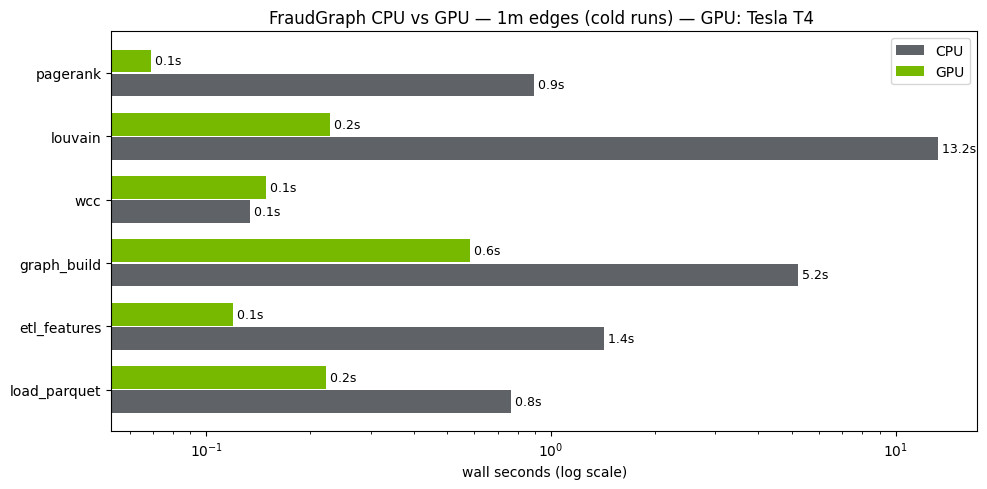

In [25]:
# 7. Benchmark chart (cold runs; DNF drawn hatched at the cap with a label).
import matplotlib.pyplot as plt
import numpy as np

cold = bench_df[~bench_df.warm].copy()
stages = ["load_parquet", "etl_features", "graph_build", "wcc", "louvain", "pagerank"]
cold = cold[cold.operation.isin(stages)]
cap_s = DNF_CAP_MINUTES * 60
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(stages))
for off, (eng, color) in enumerate([("cpu", "#5F6368"), ("gpu", "#76B900")]):
    sub = cold[cold.engine == eng].set_index("operation").reindex(stages)
    have = sub["status"].notna()
    dnf = sub["status"].astype(str).str.startswith("DNF") & have
    vals = sub["wall_seconds"].astype(float).fillna(cap_s)
    bars = ax.barh(y + (off - 0.5) * 0.38, vals.where(have, 0.0), height=0.36,
                   color=color, label=eng.upper())
    for i in range(len(stages)):
        if not bool(have.iloc[i]):
            continue
        if bool(dnf.iloc[i]):
            bars[i].set_hatch("//")
            txt = "DNF"
        else:
            txt = f"{vals.iloc[i]:,.1f}s"
        ax.text(vals.iloc[i], y[i] + (off - 0.5) * 0.38, " " + txt, va="center", fontsize=9)
ax.set_yticks(y, stages)
ax.set_xscale("log")
ax.set_xlabel("wall seconds (log scale)")
ax.set_title(f"FraudGraph CPU vs GPU — {SCALE} edges (cold runs) — {HARDWARE.split('|')[0]}")
ax.legend()
plt.tight_layout()
plt.savefig(f"benchmark_chart_{SCALE}.png", dpi=160)
plt.show()

In [ ]:
# 8. Cross-size benchmark chart: end-to-end GPU vs CPU across every size present
# in the BigQuery benchmarks table. Run this last, after all scales have been written.
def cross_size_chart():
    import matplotlib.pyplot as plt
    import numpy as np
    from google.cloud import bigquery

    client = bigquery.Client(project=PROJECT_ID)
    b = client.query(f"""
        SELECT engine, operation, n_edges, wall_seconds, status
        FROM `{PROJECT_ID}.{DATASET}.benchmarks`
        WHERE warm = FALSE
    """).to_dataframe()

    stages = ["load_parquet", "etl_features", "graph_build", "wcc", "louvain", "pagerank"]
    b = b[b.operation.isin(stages)]
    sizes = sorted(b.n_edges.unique())
    cap_s = DNF_CAP_MINUTES * 60

    def e2e(engine, n):
        rows = b[(b.engine == engine) & (b.n_edges == n)]
        if rows.empty:
            return None, "absent"
        if rows.status.astype(str).str.startswith("DNF").any():
            return cap_s, "DNF"          # any DNF stage -> end-to-end is DNF
        if rows.wall_seconds.isna().any():
            return None, "partial"
        return float(rows.wall_seconds.sum()), "ok"

    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(sizes))
    for off, (eng, color) in enumerate([("cpu", "#5F6368"), ("gpu", "#76B900")]):
        for i, n in enumerate(sizes):
            val, st = e2e(eng, n)
            if st == "absent":
                continue
            bar = ax.bar(x[i] + (off - 0.5) * 0.4, val, width=0.38, color=color,
                         label=eng.upper() if i == 0 else None,
                         hatch="//" if st == "DNF" else None)
            label = f"DNF\n>{DNF_CAP_MINUTES}m" if st == "DNF" else f"{val:,.1f}s"
            ax.text(x[i] + (off - 0.5) * 0.4, val, label, ha="center", va="bottom", fontsize=9)
    ax.set_yscale("log")
    ax.set_xticks(x, [f"{int(n/1e6)}M" for n in sizes])
    ax.set_xlabel("transaction edges")
    ax.set_ylabel("end-to-end wall seconds (log)")
    ax.set_title("FraudGraph pipeline: GPU (cuDF+cuGraph) vs CPU (pandas+NetworkX)")
    ax.legend()
    plt.tight_layout()
    plt.savefig("benchmark_chart.png", dpi=160)
    plt.show()

    print("\nEnd-to-end (cold):")
    for n in sizes:
        gv, gs = e2e("gpu", n); cv, cs = e2e("cpu", n)
        g = f"{gv:,.1f}s" if gs == "ok" else gs
        c = "DNF" if cs == "DNF" else (f"{cv:,.1f}s" if cs == "ok" else cs)
        speed = f"{cv / gv:,.0f}x" if (gs == "ok" and cs == "ok") else "—"
        print(f"  {int(n/1e6):>2}M edges: GPU {g:<10} CPU {c:<12} speedup {speed}")

if WRITE_TO_BQ:
    cross_size_chart()
else:
    print("Set WRITE_TO_BQ=True and run the scales first; then run this cell.")

## Run checklist (at `SCALE="1m"`)

- [ ] `nvidia-smi` shows a T4 (or better)
- [ ] GPU pipeline completes: load → ETL → WCC → Louvain → PageRank → Leiden → ring extraction
- [ ] CPU baseline completes (or its DNFs appear in the benchmark table)
- [ ] Leiden community count and modularity look sane (no near-singleton warning)
- [ ] Precision/recall vs ground truth printed
- [ ] Results written to BigQuery (`WRITE_TO_BQ=True`) or downloaded as CSVs
- [ ] `benchmark_chart_1m.png` saved

To build the full benchmark, rerun at `10m` (and `20m`) with `WRITE_TO_BQ=True` and
`WRITE_MODE="bench_only"`, then run the cross-size chart cell at the end.

Schema note: the `benchmarks` table carries a `status` column so capped runs are
recorded as `DNF >N min` instead of disappearing from the results.